<a href="https://colab.research.google.com/github/salilk5/Project/blob/main/AQI_Daily.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving AQI_daily_2019_Sirifort_Delhi_CPCB_2019.xlsx to AQI_daily_2019_Sirifort_Delhi_CPCB_2019 (1).xlsx


In [ ]:
import pandas as pd

file_name = 'AQI_daily_2019_Sirifort_Delhi_CPCB_2019.xlsx'
aqi_df = pd.read_excel(file_name)
display(aqi_df.head())
print(f"DataFrame shape: {aqi_df.shape}")
aqi_df.info()

,Date,January,February,March,April,May,June,July,August,September,October,November,December
0,1,405,300.0,213.0,202.0,347,283.0,202.0,217.0,107.0,242.0,494.0,271
1,2,430,350.0,235.0,238.0,322,224.0,245.0,195.0,201.0,181.0,405.0,284
2,3,453,310.0,114.0,259.0,202,290.0,152.0,204.0,264.0,188.0,498.0,275
3,4,396,262.0,237.0,335.0,181,166.0,110.0,145.0,290.0,120.0,417.0,279
4,5,411,409.0,NaN,330.0,248,205.0,97.0,82.0,216.0,118.0,326.0,354


DataFrame shape: (31, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       31 non-null     int64  
 1   January    31 non-null     int64  
 2   February   27 non-null     float64
 3   March      29 non-null     float64
 4   April      22 non-null     float64
 5   May        31 non-null     int64  
 6   June       30 non-null     float64
 7   July       29 non-null     float64
 8   August     27 non-null     float64
 9   September  30 non-null     float64
 10  October    29 non-null     float64
 11  November   30 non-null     float64
 12  December   31 non-null     int64  
dtypes: float64(9), int64(4)
memory usage: 3.3 KB


Once the file is uploaded, you can load it into a pandas DataFrame like this:

In [ ]:
missing_values_count = aqi_df.isnull().sum()
missing_values_percentage = (aqi_df.isnull().sum() / len(aqi_df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values_count,
    'Missing Percentage': missing_values_percentage
})

print("Missing values in each column:")
display(missing_info.sort_values(by='Missing Count', ascending=False))

Missing values in each column:


,Missing Count,Missing Percentage
April,9,29.032258
February,4,12.903226
August,4,12.903226
July,2,6.451613
March,2,6.451613
October,2,6.451613
September,1,3.225806
November,1,3.225806
June,1,3.225806
January,0,0.000000


In [ ]:
display(aqi_df.describe())

,Date,January,February,March,April,May,June,July,August,September,October,November,December
count,31.000000,31.000000,27.000000,29.000000,22.000000,31.000000,30.000000,29.000000,27.000000,30.000000,29.000000,30.000000,31.000000
mean,16.000000,330.193548,259.851852,244.034483,253.772727,252.967742,218.200000,162.827586,157.555556,203.766667,277.965517,325.133333,349.387097
std,9.092121,91.088023,88.187608,70.351913,60.797033,71.194327,50.011309,92.773560,74.616112,58.849125,81.364472,108.608355,82.858786
min,1.000000,92.000000,123.000000,114.000000,116.000000,152.000000,102.000000,43.000000,28.000000,66.000000,118.000000,103.000000,172.000000
25%,8.500000,270.000000,196.500000,186.000000,238.000000,190.500000,187.250000,78.000000,82.500000,168.000000,206.000000,263.250000,281.500000
50%,16.000000,354.000000,262.000000,237.000000,259.500000,248.000000,221.000000,136.000000,171.000000,209.000000,288.000000,328.000000,371.000000
75%,23.500000,401.000000,322.000000,294.000000,289.750000,317.000000,256.000000,219.000000,221.000000,239.750000,326.000000,399.000000,410.500000
max,31.000000,453.000000,430.000000,369.000000,348.000000,391.000000,291.000000,359.000000,281.000000,306.000000,413.000000,498.000000,481.000000


### Daily AQI Trend for a Specific Month

Let's visualize the daily Air Quality Index (AQI) for a chosen month to observe trends and fluctuations throughout that month. For this example, we will plot the 'January' data.

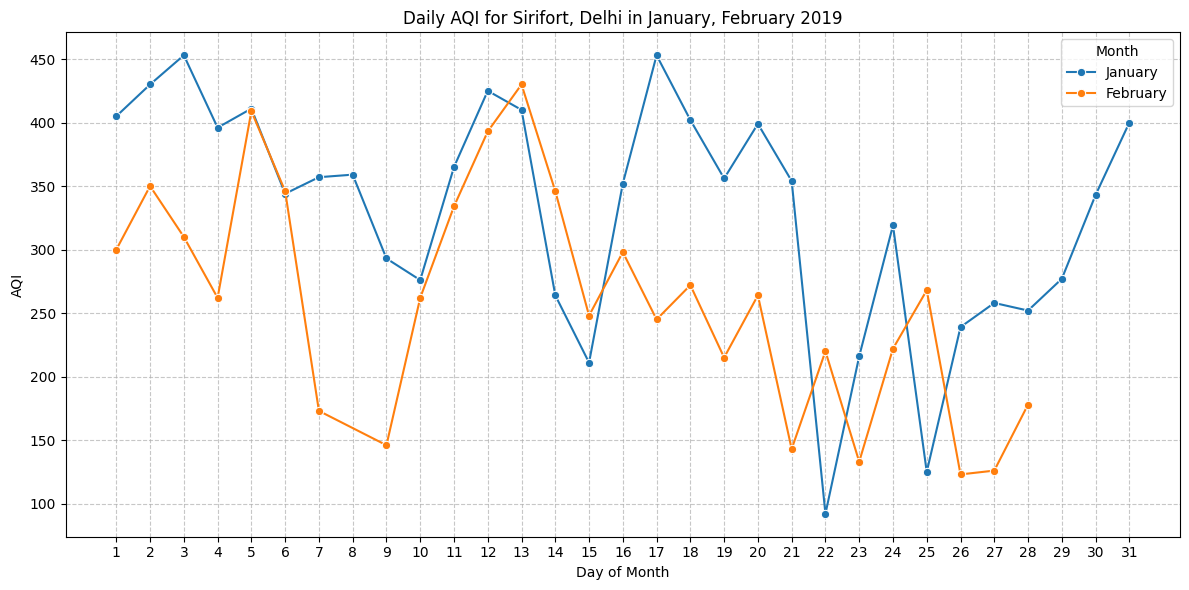

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose months to visualize
month_to_plot = ['January','February'] # Changed to a list for clarity and correct usage

# Select 'Date' and the specified month columns, then melt the DataFrame
monthly_data_long = aqi_df[['Date'] + month_to_plot].melt(id_vars=['Date'], var_name='Month', value_name='AQI').dropna()

plt.figure(figsize=(12, 6))
# Plot each month as a separate line using 'hue'
sns.lineplot(x='Date', y='AQI', hue='Month', data=monthly_data_long, marker='o')
plt.title(f'Daily AQI for Sirifort, Delhi in {', '.join(month_to_plot)} 2019') # Update title
plt.xlabel('Day of Month')
plt.ylabel('AQI')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(monthly_data_long['Date'].unique()) # Ensure all days are visible on x-axis
plt.tight_layout()
plt.show()